In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph , START , END

d:\Generative AI\env\Lib\site-packages\langchain_core\utils\pydantic.py:41: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1
d:\Generative AI\env\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
class GreetState(BaseModel):
    message: str = ""
    

In [3]:
graph = StateGraph(GreetState)

# Nodes - Python functions

In [11]:
def Greet(state : GreetState):
    state.message = f"{state.message} ! All Good !"
    return state

In [27]:
def upperCase(state : GreetState):
    state.message = state.message.upper()
    return state

In [ ]:
graph.add_node("greet", Greet)



Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Node `greet` already present.

In [30]:
graph.add_node("upper" , upperCase)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [31]:
graph.add_edge(START , "greet")
graph.add_edge("greet" , "upper")
graph.add_edge("upper" , END)



Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [32]:
finalGraph = graph.compile()

In [33]:
res = finalGraph.invoke({"message":"I love you"})
res

{'message': "HELLO , HOW'S YOU ?"}

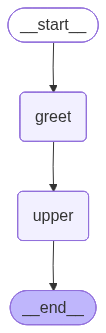

In [34]:
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png())